In [17]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
!pip install gdown
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.8 MB/s  0:00:00 eta 0:00:01
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [10]:
import pandas as pd
import geopandas as gpd
import gdown

file_id = "1QBT5er-49OkTIsnM9kgSd0FqZGohIo7-"
output = "groundsource_2026.parquet"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1QBT5er-49OkTIsnM9kgSd0FqZGohIo7-
From (redirected): https://drive.google.com/uc?id=1QBT5er-49OkTIsnM9kgSd0FqZGohIo7-&confirm=t&uuid=414d4835-af14-4ddc-92d8-5c5bfef35a96
To: /Users/macbook/Code/visdat/tubes1-visdat/notebooks/groundsource_2026.parquet
100%|██████████| 667M/667M [01:01<00:00, 10.9MB/s] 


'groundsource_2026.parquet'

In [ ]:
import ssl
import requests
import io
# 1. Membaca data mentah menggunakan Pandas
print("1. Membaca file parquet mentah (667 MB)...")
df_raw = pd.read_parquet(output)

# 2. Mengubah data biner (WKB) menjadi objek spasial GeoPandas
print("2. Mengonversi format biner WKB menjadi objek geometri...")
df_raw['geometry'] = gpd.GeoSeries.from_wkb(df_raw['geometry'])

# 3. Menjadikan GeoDataFrame dengan sistem koordinat bumi standar (EPSG:4326)
gdf_global = gpd.GeoDataFrame(df_raw, geometry='geometry', crs="EPSG:4326")

# 4. Memuat peta batas negara (MENGGUNAKAN URL LANGSUNG UNTUK GEOPANDAS 1.0+)
print("3. Memuat batas peta negara dari internet...")
ssl._create_default_https_context = ssl._create_unverified_context
url_peta_dunia = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
response = requests.get(url_peta_dunia, verify=False)
world = gpd.read_file(io.BytesIO(response.content))

# 5. Mengambil poligon peta khusus Indonesia
indonesia_map = world[world['name'] == 'Indonesia']

# 6. SPATIAL JOIN: Memfilter kejadian banjir yang berada di dalam peta Indonesia
print("4. Memfilter kejadian banjir khusus di wilayah Indonesia (proses ini mungkin butuh beberapa menit)...")
gdf_indo = gpd.sjoin(gdf_global, indonesia_map, predicate='intersects')

# 7. Membuang kolom tambahan sisa dari peta dunia, sisakan 5 kolom utama
kolom_penting = ['uuid', 'area_km2', 'geometry', 'start_date', 'end_date']
gdf_indo_final = gdf_indo[kolom_penting]

# ========================================================
# 8. DATA EXAMINATION (Sesuai Draf Laporan Langkah 2)
# ========================================================
print("\n" + "="*40)
print("HASIL DATA EXAMINATION (INDONESIA)")
print("="*40)

# A. Tinjauan Struktur
print(f"\n[A] Dimensi Data (Baris, Kolom): {gdf_indo_final.shape}")

# B. Informasi Tipe Data & Kelengkapan
print("\n[B] Informasi Tipe Data:")
gdf_indo_final.info()

print("\n[C] Jumlah Missing Values tiap kolom:")
print(gdf_indo_final.isnull().sum())

# C. Identifikasi Duplikasi
jumlah_duplikat = gdf_indo_final.duplicated(subset=['start_date', 'end_date', 'area_km2']).sum()
print(f"\n[D] Potensi jumlah baris duplikat (berdasarkan kesamaan waktu & luasan area): {jumlah_duplikat}")

# ========================================================
# 9. Menyimpan data yang sudah difilter ke format parquet lagi
# ========================================================
print("\n5. Menyimpan data khusus Indonesia ke folder processed...")
gdf_indo_final.to_parquet('../data/processed/groundsource_indonesia.parquet', index=False)
print("Semua proses selesai dengan sukses!")

1. Membaca file parquet mentah (667 MB)...
2. Mengonversi format biner WKB menjadi objek geometri...
3. Memuat batas peta negara dari internet...


/Users/macbook/Code/visdat/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


4. Memfilter kejadian banjir khusus di wilayah Indonesia (proses ini mungkin butuh beberapa menit)...

HASIL DATA EXAMINATION (INDONESIA)

[A] Dimensi Data (Baris, Kolom): (310731, 5)

[B] Informasi Tipe Data:
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 310731 entries, 36 to 2752389
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   uuid        310731 non-null  str     
 1   area_km2    310731 non-null  float64 
 2   geometry    310731 non-null  geometry
 3   start_date  310731 non-null  str     
 4   end_date    310731 non-null  str     
dtypes: float64(1), geometry(1), str(3)
memory usage: 29.7 MB

[C] Jumlah Missing Values tiap kolom:
uuid          0
area_km2      0
geometry      0
start_date    0
end_date      0
dtype: int64

[D] Potensi jumlah baris duplikat (berdasarkan kesamaan waktu & luasan area): 34

5. Menyimpan data khusus Indonesia ke folder processed...
Semua proses selesai dengan sukses!


In [14]:
# ========================================================
# 10. DATA CLEANING & QUALITY IMPROVEMENT
# ========================================================
print("Memulai proses pembersihan data...")

# A. Menghapus Duplikasi
sebelum_drop = len(gdf_indo_final)
# Menghapus duplikat berdasarkan waktu dan ukuran area yang persis sama
gdf_clean = gdf_indo_final.drop_duplicates(subset=['start_date', 'end_date', 'area_km2']).copy()
sesudah_drop = len(gdf_clean)
print(f"-> Menghapus duplikat: Berkurang dari {sebelum_drop} menjadi {sesudah_drop} baris.")

# B. Memperbaiki Tipe Data Waktu (Temporal)
# Mengubah teks menjadi format datetime agar tahunnya bisa diambil nanti
gdf_clean['start_date'] = pd.to_datetime(gdf_clean['start_date'])
gdf_clean['end_date'] = pd.to_datetime(gdf_clean['end_date'])
print("-> Konversi kolom waktu menjadi tipe datetime berhasil.")

# C. Menangani Missing Values (Bila ada)
# Menghapus baris yang tanggal mulai atau areanya kosong
gdf_clean = gdf_clean.dropna(subset=['start_date', 'area_km2', 'geometry'])
print(f"-> Baris final setelah membersihkan missing values: {len(gdf_clean)} baris.")

# D. Menyimpan Data Bersih
gdf_clean.to_parquet('../data/processed/groundsource_indonesia_clean.parquet', index=False)
print("\nData bersih berhasil disimpan ke 'groundsource_indonesia_clean.parquet'!")

Memulai proses pembersihan data...
-> Menghapus duplikat: Berkurang dari 310731 menjadi 310697 baris.
-> Konversi kolom waktu menjadi tipe datetime berhasil.
-> Baris final setelah membersihkan missing values: 310697 baris.

Data bersih berhasil disimpan ke 'groundsource_indonesia_clean.parquet'!


In [15]:
# ========================================================
# 11. DATA TRANSFORMATION & AGGREGATION
# ========================================================
print("Melakukan transformasi data...")

# A. Mengekstrak Tahun dari start_date
gdf_clean['year'] = gdf_clean['start_date'].dt.year

# B. Agregasi Data: Menghitung Frekuensi dan Total Area per Tahun
# Kita kelompokkan berdasarkan 'year'
df_trend = gdf_clean.groupby('year').agg(
    frekuensi_banjir=('uuid', 'count'),       # Menghitung jumlah kejadian
    total_area_km2=('area_km2', 'sum')        # Menjumlahkan luas area terdampak
).reset_index()

# Mengurutkan berdasarkan tahun agar rapi
df_trend = df_trend.sort_values('year')

# Menampilkan 5 tahun pertama dan 5 tahun terakhir sebagai bukti
print("\n[Hasil Transformasi] Tren Banjir 2000 - 2026:")
print(df_trend.head())
print("...")
print(df_trend.tail())

# C. Menyimpan Dataset Final (Inilah data yang akan divisualisasikan!)
df_trend.to_csv('../data/processed/trend_banjir_indonesia_2000_2026.csv', index=False)
print("\nDataset FINAL berhasil disimpan ke format CSV ('trend_banjir_indonesia_2000_2026.csv')!")

Melakukan transformasi data...

[Hasil Transformasi] Tren Banjir 2000 - 2026:
   year  frekuensi_banjir  total_area_km2
0  2000                 2     2810.673723
1  2001                 2      422.438832
2  2002                26     8314.873103
3  2003                21     2020.188209
4  2004                 8     1549.349115
...
    year  frekuensi_banjir  total_area_km2
22  2022             36675    4.259661e+06
23  2023             25850    3.184410e+06
24  2024             43075    5.663502e+06
25  2025             59246    6.494240e+06
26  2026             10934    9.272079e+05

Dataset FINAL berhasil disimpan ke format CSV ('trend_banjir_indonesia_2000_2026.csv')!


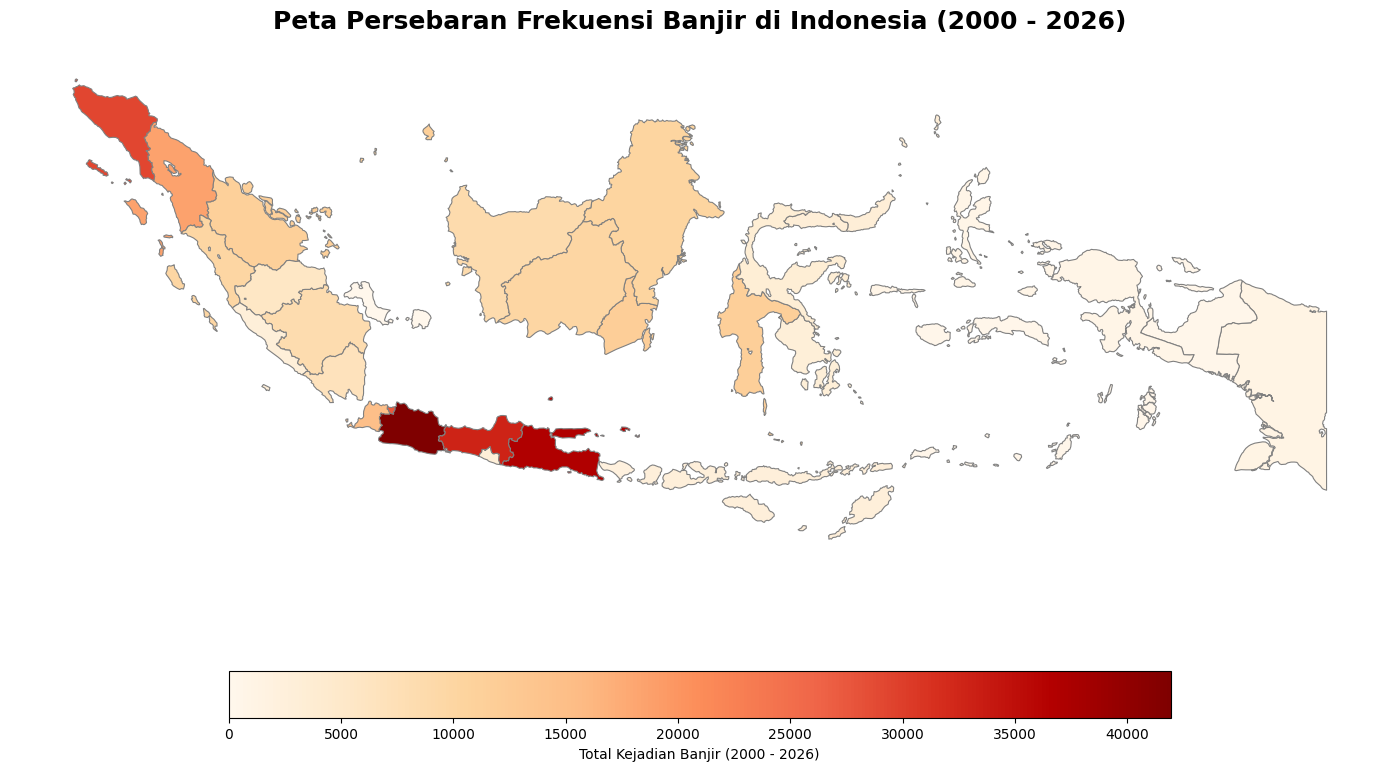


[INFO] Gambar peta berhasil disimpan ke folder 'processed' (peta_banjir_indonesia.png)!


In [31]:
import matplotlib.pyplot as plt

# 1. Menghitung total kejadian banjir untuk masing-masing provinsi secara keseluruhan (2000-2026)
# Kita gunakan variabel gdf_prov dan prov_map dari cell sebelumnya
frekuensi_prov = gdf_prov['Propinsi'].value_counts().reset_index()
frekuensi_prov.columns = ['Propinsi', 'total_kejadian']

# 2. Menggabungkan data frekuensi tadi kembali ke dalam data peta (GeoDataFrame)
map_data = prov_map.merge(frekuensi_prov, on='Propinsi', how='left')

# Jika ada provinsi yang tidak ada kejadian banjir, kita isi dengan angka 0
map_data['total_kejadian'] = map_data['total_kejadian'].fillna(0)

# ==========================================
# 3. VISUALISASI PETA (CHOROPLETH MAP)
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Membuat peta berdasarkan kolom 'total_kejadian'
# cmap='OrRd' akan memberikan gradasi warna dari Oranye ke Merah (cocok untuk kebencanaan)
map_data.plot(column='total_kejadian', 
              cmap='OrRd', 
              linewidth=0.8, 
              ax=ax, 
              edgecolor='0.5', # Warna garis batas provinsi (abu-abu)
              legend=True,
              legend_kwds={'label': "Total Kejadian Banjir (2000 - 2026)", 
                           'orientation': "horizontal",
                           'shrink': 0.6}) # Memperkecil ukuran bar legenda

# Pengaturan Judul dan Tampilan
ax.set_title('Peta Persebaran Frekuensi Banjir di Indonesia (2000 - 2026)', 
             fontsize=18, fontweight='bold', pad=20)

# Mematikan sumbu X dan Y agar terlihat bersih seperti peta sungguhan
ax.axis('off')

# Menyesuaikan layout agar rapi
fig.tight_layout()

# Menampilkan peta
plt.show()

# 4. (Opsional) Menyimpan Peta ke format gambar transparan tinggi resolusi (PNG) untuk dimasukkan ke Figma/Illustrator
fig.savefig('../data/processed/peta_banjir_indonesia.png', dpi=300, transparent=True)
print("\n[INFO] Gambar peta berhasil disimpan ke folder 'processed' (peta_banjir_indonesia.png)!")